## Basit Lineer Regresyon (Model)

*Veri seti hikayesini kısaca açıklamak gerekirse bir reklam ajansının farklı platformlara vermiş olduğu reklam kampanyasından elde ettiği gelirleri ifade ediyor.*

In [1]:
#Keşifçi Veri Analizi

In [2]:
import pandas as pd
ad = pd.read_csv("Advertising.csv")
df = ad.copy()
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
#Gereksiz Sütunun Kaldırılması

In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
#Veri setinin genel yapısı

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
#Betimleyici istatistikler

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [10]:
#Eksik veri kontrolü

In [11]:
df.isnull().values.any()

np.False_

In [12]:
#Korelasyon analizi

In [13]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


- **TV → sales:** 0.78 → Güçlü pozitif korelasyon. Basit Doğrusal Regresyon için en uygun bağımsız değişken.
- **radio → sales:** 0.58 → Orta düzey korelasyon.
- **newspaper → sales:** 0.23 → Zayıf korelasyon.

*Burada **TV** bağımsız değişkeni kullanılarak güçlü bir regresyon modeli oluşturabiliriz fakat bu demek değildir ki sadece TV değişkeni ile oluşturulabilir. Örneğin radio değişkeni ile de model kurulabilir çünkü orta şiddetli bir korelasyon var. **radio** ile TV arasında çok düşük bir korelasyon var yani neredeyse birbirlerini etkilemiyorlar. Satışlardaki farklı bir varyasyonu radio değişkeni ile de açıklayabiliriz demek bu.*

In [14]:
#Görselleştirme 

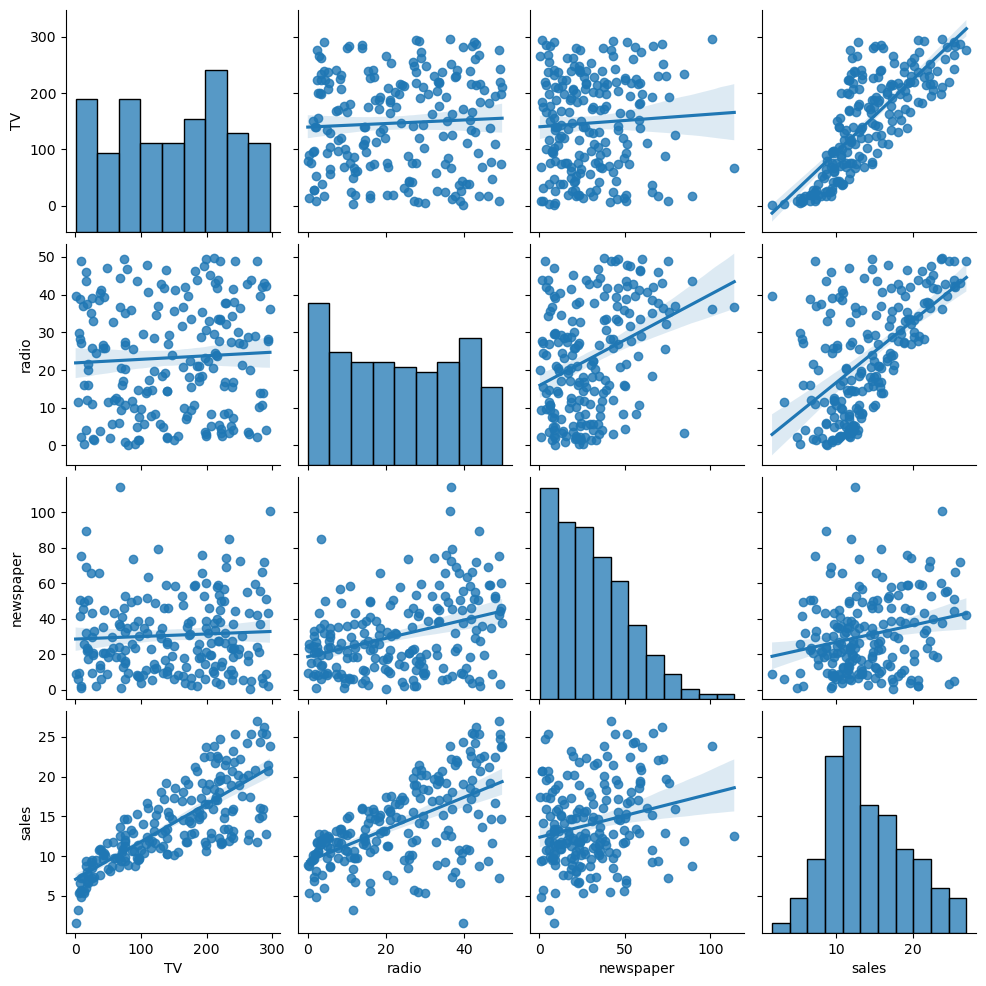

In [15]:
import seaborn as sns
sns.pairplot(df, kind = "reg");

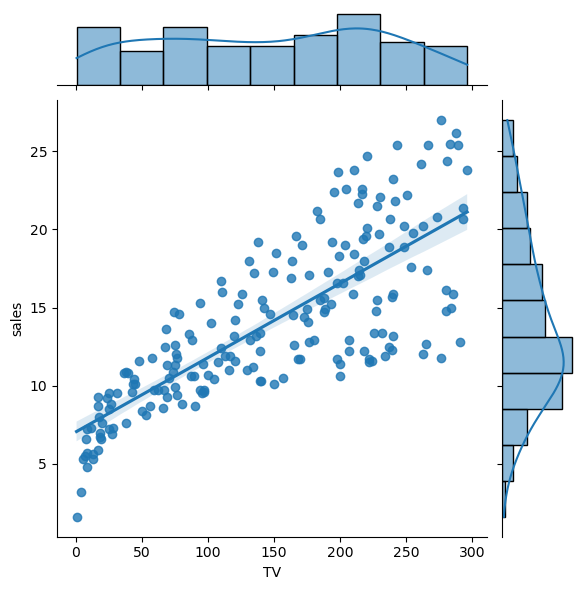

In [16]:
sns.jointplot(x = "TV", y = "sales", data = df, kind = "reg");

## Model Kurulumu

Keşifçi veri analizinde gördüğümüz üzere **TV** bağımsız değişkeni ile **sales** bağımlı değişkeni arasında güçlü bir doğrusal ilişki var (korelasyon: 0.78). Bu nedenle Basit Doğrusal Regresyon modelimizi **TV → sales** üzerine kuruyoruz.

In [17]:
#Model kurulumu (manuel)

In [18]:
#Bağımsız değişken seçimi

In [19]:
import statsmodels.api as sm
X = df["TV"]
X.head()

0    230.1
1     44.5
2     17.2
3    151.5
4    180.8
Name: TV, dtype: float64

In [20]:
#Sabit terim ekleme

In [21]:
X = sm.add_constant(X)
X.head()

,const,TV
0,1.0,230.1
1,1.0,44.5
2,1.0,17.2
3,1.0,151.5
4,1.0,180.8


In [22]:
#Bağımlı değişken seçimi

In [23]:
y = df["sales"]
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64

In [24]:
#Model tanımlama

In [25]:
lm = sm.OLS(y, X)

In [26]:
#Model eğitimi

In [27]:
model = lm.fit()

In [28]:
#Model çıktı özeti

In [29]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.47e-42
Time:                        21:28:11   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Model Sonuçlarının Yorumlanması

####  R-squared = 0.612
*TV reklam harcamaları, satışlardaki değişkenliğin **%61.2'sini** açıklıyor. Yani modelimiz satışlardaki toplam varyasyonun yaklaşık %61'ini yakalıyor. Kalan %38.8 ise modelde yer almayan diğer faktörlerden kaynaklanıyor.*

####  Adj. R-squared = 0.610
*Bağımsız değişken sayısını göz önünde bulundurarak hesaplanan R² değeri. Basit Lineer Regresyonda R² ile çok yakın çıkar. Çoklu regresyona geçince önem kazanır. modele gereksiz değişken eklendiğinde R² her zaman artar, ama Adj. R² bu durumda ceza uygulayarak gerçekçi bir ölçüm sunar.*

####  F-statistic = 312.1 ve Prob(F-statistic) = 1.47e-42
***F istatistiği**, modelin bir bütün olarak istatistiksel anlamlılığını test eder. Basit lineer regresyonda F = t² ilişkisi vardır: 17.668² ≈ 312.1. F değeri büyüdükçe model daha güçlü anlamlıdır.*

***Prob(F-statistic)** ise F istatistiği için p-değeridir. 1.47e-42 ≈ 0.000 değeri, 0.05'ten çok daha küçük olduğundan modelimiz **istatistiksel olarak anlamlıdır**. TV reklam harcamaları satışları açıklamada gerçekten anlamlı bir katkı sağlıyor.*


##  Katsayı Tablosu Yorumu

#### const (b₀ = 7.0326) - Sabit Terim
*TV reklam harcaması 0 olduğunda beklenen satış miktarı **7.03 birimdir**.*
- ***t = 15.360:** Yüksek t değeri, b₀'ın sıfırdan anlamlı şekilde farklı olduğunu gösteriyor.*
- ***P>|t| = 0.000:** P-değeri 0.05'ten çok küçük → b₀ **istatistiksel olarak anlamlı**.*
- ***%95 Güven Aralığı [6.130, 7.935]:** Gerçek b₀ değerinin %95 olasılıkla bu aralıkta olduğunu söylüyor.*

#### TV (b₁ = 0.0475) - Eğim Katsayısı
*TV reklam harcaması **1 birim** artınca satışlar **0.0475 birim** artıyor. Yani tahmin fonksiyonumuz: **ŷ = 7.0326 + 0.0475 × TV***
- ***t = 17.668:** Yüksek t değeri, TV'nin satışlar üzerinde güçlü bir etkisinin olduğunu gösteriyor.*
- ***P>|t| = 0.000:** P-değeri 0.05'ten çok küçük → b₁ **istatistiksel olarak anlamlı**.*
- ***%95 Güven Aralığı [0.042, 0.053]:** Gerçek eğim katsayısının %95 olasılıkla bu aralıkta olduğunu söylüyor.*

***Genel Değerlendirme:** Model istatistiksel açıdan anlamlı ve TV değişkeni satışları açıklamada önemli bir rol oynuyor. Ancak R² = 0.612 değeri satışların %38.8'inin hâlâ açıklanamadığını gösteriyor. Gerçek hayatta böyle bir modelin yetersiz olacağı aşikardır çünkü reklam satışlarında kalan %40 lık bir oranın nasıl sağlandığı bilgisini halen öğrenemiyoruz.*

In [30]:
#Alternatif Model Kurulumu (otomatik)

In [31]:
import statsmodels.formula.api as smf
lm = smf.ols("sales ~ TV", data = df)
model = lm.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.47e-42
Time:                        21:28:15   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
#Model parametreleri

In [33]:
model.params

Intercept    7.032594
TV           0.047537
dtype: float64

In [34]:
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,7.0326,0.458,15.360,0.000,6.130,7.935
TV,0.0475,0.003,17.668,0.000,0.042,0.053


In [35]:
#Güven aralıklarına erişim

In [36]:
model.conf_int()

,0,1
Intercept,6.129719,7.935468
TV,0.042231,0.052843


In [37]:
#f testinin p değeri

In [38]:
model.f_pvalue

np.float64(1.4673897001946295e-42)

In [39]:
print("f_pvalue: ", "%.4f" % model.f_pvalue)

f_pvalue:  0.0000


In [40]:
#f istatistiği

In [41]:
print("fvalue: ", "%.2f" % model.fvalue)

fvalue:  312.14


In [42]:
#t istatistiği

In [43]:
print("tvalue: ", "%.2f" % model.tvalues.iloc[0])

tvalue:  15.36


In [44]:
#ortalama kare hata

In [45]:
model.mse_model

np.float64(3314.618166868649)

In [46]:
model.rsquared

np.float64(0.611875050850071)

In [47]:
model.rsquared_adj

np.float64(0.6099148238341623)

In [48]:
#tahmin edilen ilk 5 değer

In [49]:
model.fittedvalues[0:5]

0    17.970775
1     9.147974
2     7.850224
3    14.234395
4    15.627218
dtype: float64

In [50]:
#gerçek değerler

In [51]:
y[0:5]

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64

In [52]:
#modelin üretmiş olduğu tahmin fonksiyonu

In [53]:
print("Sales = " +  str("%.2f" % model.params.iloc[0]) + " + TV" + "*" + str("%.2f" % model.params.iloc[1]))

Sales = 7.03 + TV*0.05


*İşte bütün her şey yukarıdaki tahmin fonksiyonunu bulmak içindi. Fakat iş burda bitmiyor. Önemli olan sadece tahmin fonksiyonunu bulmak değil, aynı zamanda gerçek değerleri nokta atışı ile tespit edebilecek en optimum parametreleri bulmaktır. Bunun için ise parametre tuning,model tuning gibi işlemler uygulanır.*

In [54]:
#Tahmini regresyon model grafiği

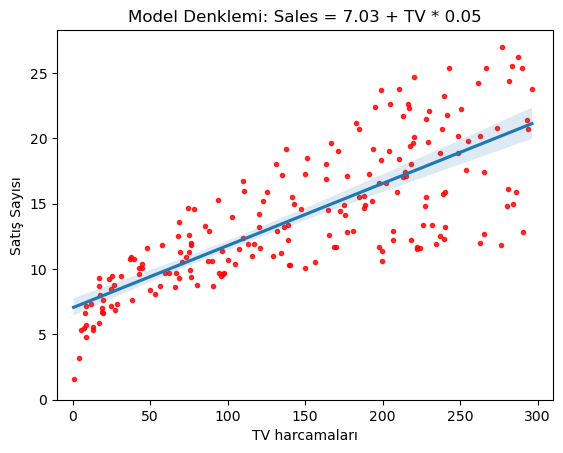

In [55]:
import matplotlib.pyplot as plt
g = sns.regplot(x = df["TV"], y = df["sales"], ci = 95, scatter_kws = {'color' : 'r', 's' : 9})
g.set_title("Model Denklemi: Sales = 7.03 + TV * 0.05")
g.set_ylabel("Satış Sayısı")
g.set_xlabel("TV harcamaları")
plt.xlim(-10, 310)
plt.ylim(bottom = 0);

## Sklearn ile Model Kurulumu

*Bütün makine öğrenmesi algoritmalarını kapsayan kapsamlı bir framework'tür. İlk başta statsmodels kullandık çünkü model çıktılarını sklearn'e göre çok daha kapsamlı bir şekilde ele alıyor.*

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
X = df[["TV"]]
y = df["sales"]
reg = LinearRegression()
model = reg.fit(X, y)

In [58]:
print(" sabit parametre değeri : " + str("%.2f" % model.intercept_))
print(" bağımsız değişken katsayısı : " + str("%.2f" % model.coef_[0]))

 sabit parametre değeri : 7.03
 bağımsız değişken katsayısı : 0.05


In [59]:
#model skoru

In [60]:
model.score(X,y)

0.611875050850071

In [61]:
#tahmin edilen ilk 10 değere ulaşma

In [62]:
model.predict(X)[0:10]

array([17.97077451,  9.14797405,  7.85022376, 14.23439457, 15.62721814,
        7.44616232,  9.76595037, 12.74649773,  7.44140866, 16.53041431])

## Tahmin

*Model Denklemi: <br>
Sales = 7.03 + TV * 0.04*

*Örneğin 30 birim TV harcaması olduğunda satışların tahmini ne olur ?*

In [63]:
model.predict([[30]])

C:\Users\tcmur\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([8.45869276])

*TV , radio ve newspaper departmanlarında sırayla 5, 90 ve 200 birim harcamalar olursa satış tahminleri ne olur ?*

In [64]:
expenses = [[5],[90],[200]]

In [65]:
model.predict(expenses)

C:\Users\tcmur\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 7.27027675, 11.31089119, 16.53992164])

*Küçük bir not: Modeli eğitirken dataframe kullandık, tahmin yaparken de parametre olarak array ve liste giriyoruz. Bu yüzden python bizi uyarıyor. Çözümü ise tahmin yaparken de dataframe kullanmak fakat böyle kullanmak daha uygun gibi.*